# NorthStar Urban Mobility and Logistics
## Section 2 — Data Analytics in Python


### Cell 1 — Install and Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries loaded successfully.')

All libraries loaded successfully.


### Cell 2 — Load All Datasets from GitHub

In [ ]:
base_url = 'https://raw.githubusercontent.com/Insia-8/NorthStar_Dataset/main/'

orders     = pd.read_csv(base_url + 'orders.csv')
deliveries = pd.read_csv(base_url + 'deliveries.csv')
drivers    = pd.read_csv(base_url + 'drivers.csv')
customers  = pd.read_csv(base_url + 'customers.csv')
hubs       = pd.read_csv(base_url + 'hubs.csv')
complaints = pd.read_csv(base_url + 'complaints.csv')
incidents  = pd.read_csv(base_url + 'incidents.csv')
vehicles   = pd.read_csv(base_url + 'vehicles.csv')
app_events = pd.read_csv(base_url + 'app_events.csv')

datasets = {
    'orders': orders, 'deliveries': deliveries, 'drivers': drivers,
    'customers': customers, 'hubs': hubs, 'complaints': complaints,
    'incidents': incidents, 'vehicles': vehicles, 'app_events': app_events
}

print('All datasets loaded successfully.')
for name, df in datasets.items():
    print(f'  {name:<15}: {df.shape[0]:>5} rows x {df.shape[1]:>2} cols')

All datasets loaded successfully.
  orders         :  1250 rows x 11 cols
  deliveries     :   950 rows x 13 cols
  drivers        :   170 rows x  8 cols
  customers      :   650 rows x  9 cols
  hubs           :     8 rows x  5 cols
  complaints     :   320 rows x 10 cols
  incidents      :   280 rows x  7 cols
  vehicles       :   120 rows x  8 cols
  app_events     :   640 rows x 10 cols


### Cell 3 — Exploratory Data Analysis (EDA)


In [ ]:
# --- Shape and dtypes ---
print('===== DATA TYPES =====')
for name, df in datasets.items():
    print(f'\n{name}:')
    print(df.dtypes.to_string())

===== DATA TYPES =====

orders:
order_id                  object
customer_id               object
service_type              object
order_created_at          object
promised_window_hours      int64
pickup_zone               object
dropoff_zone              object
priority_level            object
order_value              float64
booking_channel           object
special_handling_flag      int64

deliveries:
delivery_id                       object
order_id                          object
driver_id                         object
vehicle_id                        object
hub_id                            object
dispatch_time                     object
delivery_completed_at             object
delivery_status                   object
route_distance_km                float64
manual_route_override_count        int64
proof_of_completion_missing        int64
customer_rating_post_delivery    float64
fuel_or_charge_cost              float64

drivers:
driver_id            object
base_zone            

In [ ]:
print('===== MISSING VALUES =====')
for name, df in datasets.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f'\n{name}:')
        for col, cnt in nulls.items():
            pct = round(cnt / len(df) * 100, 1)
            print(f'  {col:<35}: {cnt:>4} missing ({pct}%)')

===== MISSING VALUES =====

orders:
  booking_channel                    :   25 missing (2.0%)

deliveries:
  delivery_completed_at              :   19 missing (2.0%)
  customer_rating_post_delivery      :   14 missing (1.5%)

drivers:
  training_score                     :    7 missing (4.1%)

customers:
  loyalty_score                      :   20 missing (3.1%)
  preferred_channel                  :   13 missing (2.0%)

complaints:
  compensation_amount                :   16 missing (5.0%)

incidents:
  resolved_hours                     :   17 missing (6.1%)

vehicles:
  battery_health_pct                 :    4 missing (3.3%)

app_events:
  order_id                           :  144 missing (22.5%)


In [ ]:
print('===== ORDERS — DESCRIPTIVE STATS =====')
print(orders[['order_value','promised_window_hours']].describe().round(2))
print('\n===== DELIVERIES — DESCRIPTIVE STATS =====')
print(deliveries[['route_distance_km','manual_route_override_count',
                   'customer_rating_post_delivery','fuel_or_charge_cost']].describe().round(2))
print('\n===== CUSTOMERS — DESCRIPTIVE STATS =====')
print(customers[['age','loyalty_score','app_engagement_score']].describe().round(2))

===== ORDERS — DESCRIPTIVE STATS =====
       order_value  promised_window_hours
count      1250.00                1250.00
mean         91.05                   7.62
std          60.92                   7.06
min           2.04                   1.00
25%          47.92                   4.00
50%          76.53                   6.00
75%         121.10                  12.00
max         510.06                  24.00

===== DELIVERIES — DESCRIPTIVE STATS =====
       route_distance_km  manual_route_override_count  \
count             950.00                       950.00   
mean               13.91                         0.97   
std                 7.48                         1.09   
min                 1.20                         0.00   
25%                 9.14                         0.00   
50%                12.84                         1.00   
75%                16.84                         2.00   
max                41.94                         7.00   

       customer_rating_po

### Cell 4 — Data Cleaning: Zone Standardisation
**Problem:** Zone columns contain 16+ inconsistent variants across all files.
**Fix:** Map all variants to canonical Title Case.

In [ ]:
zone_map = {
    'NORTH': 'North', 'north': 'North',
    'SOUTH': 'South', 'south': 'South',
    'EAST': 'East',   'east': 'East',
    'WEST': 'West',   'west': 'West',
    'CENTRAL': 'Central', 'CTR': 'Central', 'Ctr': 'Central',
    'AIRPORT': 'Airport', 'airport': 'Airport',
    'RIVERSIDE': 'Riverside', 'RiverSide': 'Riverside'
}

def clean_zone(series):
    return series.str.strip().replace(zone_map)

orders['pickup_zone']       = clean_zone(orders['pickup_zone'])
orders['dropoff_zone']      = clean_zone(orders['dropoff_zone'])
customers['home_zone']      = clean_zone(customers['home_zone'])
vehicles['assigned_zone']   = clean_zone(vehicles['assigned_zone'])
drivers['base_zone']        = clean_zone(drivers['base_zone'])
app_events['zone_context']  = clean_zone(app_events['zone_context'])

print('Unique zones after cleaning:')
print(sorted(orders['pickup_zone'].unique()))

print('\nZone frequency in orders (pickup_zone):')
print(orders['pickup_zone'].value_counts())

Unique zones after cleaning:
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']

Zone frequency in orders (pickup_zone):
pickup_zone
Central      238
East         207
South        181
North        174
West         155
Riverside    151
Airport      144
Name: count, dtype: int64


### Cell 5 — Missing Value Handling


In [ ]:
# orders: booking_channel — 25 missing → fill with 'Unknown'
orders['booking_channel'] = orders['booking_channel'].fillna('Unknown')
print('orders booking_channel nulls after fix:', orders['booking_channel'].isnull().sum())

# customers: loyalty_score — 20 missing → fill with median (robust to outliers)
median_loyalty = customers['loyalty_score'].median()
customers['loyalty_score'] = customers['loyalty_score'].fillna(median_loyalty)
print(f'customers loyalty_score: filled {20} nulls with median={median_loyalty:.2f}')

# customers: preferred_channel — 13 missing → fill with mode
mode_channel = customers['preferred_channel'].mode()[0]
customers['preferred_channel'] = customers['preferred_channel'].fillna(mode_channel)
print(f'customers preferred_channel: filled nulls with mode={mode_channel}')

# drivers: training_score — 7 missing → fill with mean
mean_training = drivers['training_score'].mean()
drivers['training_score'] = drivers['training_score'].fillna(mean_training)
print(f'drivers training_score: filled nulls with mean={mean_training:.2f}')

# deliveries: customer_rating — 14 missing → keep as NaN (truly unknown ratings)
print(f'deliveries customer_rating: keeping {deliveries["customer_rating_post_delivery"].isnull().sum()} NaNs — ratings not given')

# complaints: compensation_amount — 16 missing → fill with 0 (no compensation given)
complaints['compensation_amount'] = complaints['compensation_amount'].fillna(0)
print(f'complaints compensation_amount: filled nulls with 0')

print('\nMissing value handling complete.')

orders booking_channel nulls after fix: 0
customers loyalty_score: filled 20 nulls with median=59.60
customers preferred_channel: filled nulls with mode=App
drivers training_score: filled nulls with mean=74.91
deliveries customer_rating: keeping 14 NaNs — ratings not given
complaints compensation_amount: filled nulls with 0

Missing value handling complete.


### Cell 6 — Feature Engineering


In [ ]:
# Parse datetime columns
deliveries['dispatch_time']         = pd.to_datetime(deliveries['dispatch_time'])
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'])
orders['order_created_at']          = pd.to_datetime(orders['order_created_at'])
complaints['created_at']            = pd.to_datetime(complaints['created_at'])

# 1. Actual delivery duration in hours
deliveries['actual_hours'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600

# 2. Time anomaly flag (completed before dispatched)
deliveries['time_anomaly_flag'] = (deliveries['actual_hours'] < 0).astype(int)
print(f'Time anomalies flagged: {deliveries["time_anomaly_flag"].sum()}')

# 3. Set anomalous durations to NaN
deliveries.loc[deliveries['time_anomaly_flag'] == 1, 'actual_hours'] = np.nan

# 4. Delay flag (Failed or Delayed)
deliveries['delay_flag'] = deliveries['delivery_status'].isin(['Failed','Delayed']).astype(int)
print(f'Delayed/Failed deliveries: {deliveries["delay_flag"].sum()} of {len(deliveries)}')

# 5. Override rate per km
deliveries['override_rate'] = (
    deliveries['manual_route_override_count'] / deliveries['route_distance_km']
).round(4)

# 6. Profit margin per delivery
merged_temp = deliveries.merge(orders[['order_id','order_value']], on='order_id', how='left')
deliveries['profit_margin'] = (
    merged_temp['order_value'] - deliveries['fuel_or_charge_cost']
).round(2)

# 7. Repeat complainer flag on customers
complaint_counts = complaints.groupby('customer_id').size().reset_index(name='complaint_count')
customers = customers.merge(complaint_counts, on='customer_id', how='left')
customers['complaint_count'] = customers['complaint_count'].fillna(0).astype(int)
customers['is_repeat_complainer'] = (customers['complaint_count'] >= 2).astype(int)
print(f'Repeat complainers: {customers["is_repeat_complainer"].sum()}')

# 8. Order month
orders['order_month'] = orders['order_created_at'].dt.to_period('M').astype(str)

print('\nNew features created:')
print(deliveries[['actual_hours','time_anomaly_flag','delay_flag',
                   'override_rate','profit_margin']].describe().round(3))

Time anomalies flagged: 64
Delayed/Failed deliveries: 334 of 950
Repeat complainers: 74

New features created:
       actual_hours  time_anomaly_flag  delay_flag  override_rate  \
count        867.00             950.00      950.00         950.00   
mean          10.32               0.07        0.35           0.10   
std            8.46               0.25        0.48           0.19   
min            0.02               0.00        0.00           0.00   
25%            3.50               0.00        0.00           0.00   
50%            7.91               0.00        0.00           0.06   
75%           15.53               0.00        1.00           0.12   
max           43.46               1.00        1.00           2.10   

       profit_margin  
count         950.00  
mean           79.02  
std            62.26  
min            -9.42  
25%            36.08  
50%            64.11  
75%           109.73  
max           489.52  


### Cell 7 — Statistical Analysis with NumPy


In [ ]:
print('===== NumPy Statistics — Order Value =====')
ov = orders['order_value'].dropna().values
print(f'  Mean:     {np.mean(ov):.2f}')
print(f'  Median:   {np.median(ov):.2f}')
print(f'  Std Dev:  {np.std(ov):.2f}')
print(f'  Min:      {np.min(ov):.2f}')
print(f'  Max:      {np.max(ov):.2f}')
print(f'  Q1:       {np.percentile(ov, 25):.2f}')
print(f'  Q3:       {np.percentile(ov, 75):.2f}')
print(f'  IQR:      {np.percentile(ov, 75) - np.percentile(ov, 25):.2f}')

print('\n===== NumPy Statistics — Fuel/Charge Cost =====')
fc = deliveries['fuel_or_charge_cost'].dropna().values
print(f'  Mean:     {np.mean(fc):.2f}')
print(f'  Median:   {np.median(fc):.2f}')
print(f'  Std Dev:  {np.std(fc):.2f}')
print(f'  Min:      {np.min(fc):.2f}')
print(f'  Max:      {np.max(fc):.2f}')

print('\n===== NumPy Statistics — Customer Rating =====')
cr = deliveries['customer_rating_post_delivery'].dropna().values
print(f'  Mean:     {np.mean(cr):.2f}')
print(f'  Median:   {np.median(cr):.2f}')
print(f'  Std Dev:  {np.std(cr):.2f}')

print('\n===== Pearson Correlation — Training Score vs Driver Rating =====')
ts = drivers['training_score'].dropna().values
dr = drivers['driver_rating'].dropna().values
min_len = min(len(ts), len(dr))
corr, pval = stats.pearsonr(ts[:min_len], dr[:min_len])
print(f'  Correlation: {corr:.4f} | p-value: {pval:.4f}')
print(f'  Interpretation: {"Significant" if pval < 0.05 else "Not significant"} relationship')

===== NumPy Statistics — Order Value =====
  Mean:     91.05
  Median:   76.53
  Std Dev:  60.89
  Min:      2.04
  Max:      510.06
  Q1:       47.91
  Q3:       121.10
  IQR:      73.18

===== NumPy Statistics — Fuel/Charge Cost =====
  Mean:     12.84
  Median:   12.64
  Std Dev:  4.33
  Min:      2.50
  Max:      29.43

===== NumPy Statistics — Customer Rating =====
  Mean:     3.86
  Median:   4.04
  Std Dev:  0.89

===== Pearson Correlation — Training Score vs Driver Rating =====
  Correlation: -0.0685 | p-value: 0.3747
  Interpretation: Not significant relationship


### Cell 8 — Data Analysis with Pandas


In [ ]:

master = orders.merge(deliveries, on='order_id', how='left')
master = master.merge(drivers, on='driver_id', how='left')
master = master.merge(customers, on='customer_id', how='left')
master = master.merge(hubs, on='hub_id', how='left')
print(f'Master dataframe shape: {master.shape}')

print('\n===== Delivery Performance by Zone =====')
zone_perf = master.groupby('zone').agg(
    total_deliveries  = ('delivery_id', 'count'),
    failure_rate_pct  = ('delay_flag', lambda x: round(x.mean()*100, 1)),
    avg_rating        = ('customer_rating_post_delivery', lambda x: round(x.mean(), 2)),
    avg_fuel_cost     = ('fuel_or_charge_cost', lambda x: round(x.mean(), 2)),
    avg_order_value   = ('order_value', lambda x: round(x.mean(), 2)),
    avg_overrides     = ('override_rate', lambda x: round(x.mean(), 3))
).reset_index().sort_values('failure_rate_pct', ascending=False)
print(zone_perf.to_string(index=False))

print('\n===== Revenue vs Cost by Service Type =====')
svc_finance = master.groupby('service_type').agg(
    orders            = ('order_id', 'count'),
    total_revenue     = ('order_value', 'sum'),
    total_fuel_cost   = ('fuel_or_charge_cost', 'sum'),
    avg_profit_margin = ('profit_margin', 'mean')
).round(2).reset_index()
svc_finance['net_profit'] = (svc_finance['total_revenue'] - svc_finance['total_fuel_cost']).round(2)
print(svc_finance.to_string(index=False))

Master dataframe shape: (1250, 50)

===== Delivery Performance by Zone =====
     zone  total_deliveries  failure_rate_pct  avg_rating  avg_fuel_cost  avg_order_value  avg_overrides
  Airport               104             40.40        3.88          13.32            86.33           0.09
  Central               243             39.50        3.78          12.64            93.95           0.11
     West               127             34.60        3.92          13.17            90.06           0.09
    South               106             34.00        3.95          12.57            90.35           0.08
Riverside               115             33.90        3.88          12.92            89.93           0.11
    North               136             31.60        3.84          12.76            91.75           0.10
     East               119             28.60        3.90          12.74            97.68           0.09

===== Revenue vs Cost by Service Type =====
service_type  orders  total_revenue  t

In [ ]:
# Cell 8b — Why Does Airport Zone Fail Most?

master2 = master.merge(vehicles[['vehicle_id','vehicle_type',
                                  'battery_health_pct','maintenance_status']],
                        on='vehicle_id', how='left')

airport_df = master2[master2['zone'] == 'Airport'].copy()

print("=== Airport Zone — Vehicle Type Breakdown ===")
print(airport_df.groupby('vehicle_type')['delay_flag']
      .agg(total='count',
           failures=lambda x: x.sum(),
           failure_rate=lambda x: round(x.mean()*100, 1))
      .sort_values('failure_rate', ascending=False))

print("\n=== Airport Zone — Driver Employment Type Breakdown ===")
print(airport_df.groupby('employment_type')['delay_flag']
      .agg(total='count',
           failures=lambda x: x.sum(),
           failure_rate=lambda x: round(x.mean()*100, 1))
      .sort_values('failure_rate', ascending=False))

print("\n=== Airport Zone — Average Override Count vs Other Zones ===")
print(master2.groupby('zone')['manual_route_override_count']
      .mean().round(2).sort_values(ascending=False))

print("\n=== Airport Zone — Vehicle Maintenance Status ===")
print(airport_df['maintenance_status'].value_counts())

print("\n=== Airport Zone — Battery Health Summary ===")
print(airport_df.groupby('vehicle_type')['battery_health_pct']
      .describe().round(1))

=== Airport Zone — Vehicle Type Breakdown ===
              total  failures  failure_rate
vehicle_type                               
CargoVan         28     12.00         42.90
Hybrid           29     12.00         41.40
Diesel           15      6.00         40.00
EV               32     12.00         37.50

=== Airport Zone — Driver Employment Type Breakdown ===
                 total  failures  failure_rate
employment_type                               
Contract            12      6.00         50.00
PartTime            30     12.00         40.00
FullTime            62     24.00         38.70

=== Airport Zone — Average Override Count vs Other Zones ===
zone
Riverside   1.05
North       1.03
Central     1.03
South       0.92
Airport     0.91
East        0.89
West        0.87
Name: manual_route_override_count, dtype: float64

=== Airport Zone — Vehicle Maintenance Status ===
maintenance_status
Active       59
InRepair     32
Scheduled    13
Name: count, dtype: int64

=== Airport Zone 

**Interpretation:** The Airport zone failure rate (40.4%) cannot be attributed to a single cause — all vehicle types fail at broadly similar rates (37–43%), and driver employment type shows contract drivers failing most (50%) but full-time drivers are not far behind (38.7%). The most significant finding is maintenance status: 32 out of 104 Airport zone deliveries (30.8%) involve vehicles marked InRepair — vehicles that should not be on active routes. CargoVans show the lowest average battery health (71.7%) and the highest failure rate (42.9%), suggesting vehicle condition is a stronger predictor of Airport zone failure than driver type or route difficulty. Override counts in Airport zone are actually below average (0.91 vs 1.05 in Riverside), ruling out poor route planning as a cause. NorthStar should prioritise vehicle maintenance compliance in the Airport zone before reassigning drivers or adjusting routes.

### Cell 9 — Correlation Matrix (Pandas)


In [ ]:
numeric_cols = ['order_value','promised_window_hours','route_distance_km',
                'manual_route_override_count','customer_rating_post_delivery',
                'fuel_or_charge_cost','years_experience','training_score',
                'driver_rating','age','loyalty_score','app_engagement_score',
                'actual_hours','delay_flag','profit_margin']

corr_matrix = master[numeric_cols].corr().round(3)
print('Correlation Matrix (key pairs):')
print(corr_matrix[['customer_rating_post_delivery','delay_flag',
                    'profit_margin','training_score']].to_string())

Correlation Matrix (key pairs):
                               customer_rating_post_delivery  delay_flag  profit_margin  training_score
order_value                                            -0.00       -0.03           1.00            0.04
promised_window_hours                                   0.05       -0.06           0.01            0.04
route_distance_km                                       0.03        0.02           0.02           -0.07
manual_route_override_count                            -0.06        0.06           0.01            0.01
customer_rating_post_delivery                           1.00       -0.64           0.00            0.00
fuel_or_charge_cost                                    -0.06        0.05          -0.10           -0.02
years_experience                                       -0.06        0.10           0.03            0.16
training_score                                          0.00        0.04           0.04            1.00
driver_rating                   

### Cell 10 — Visualisation 1: Correlation Heatmap


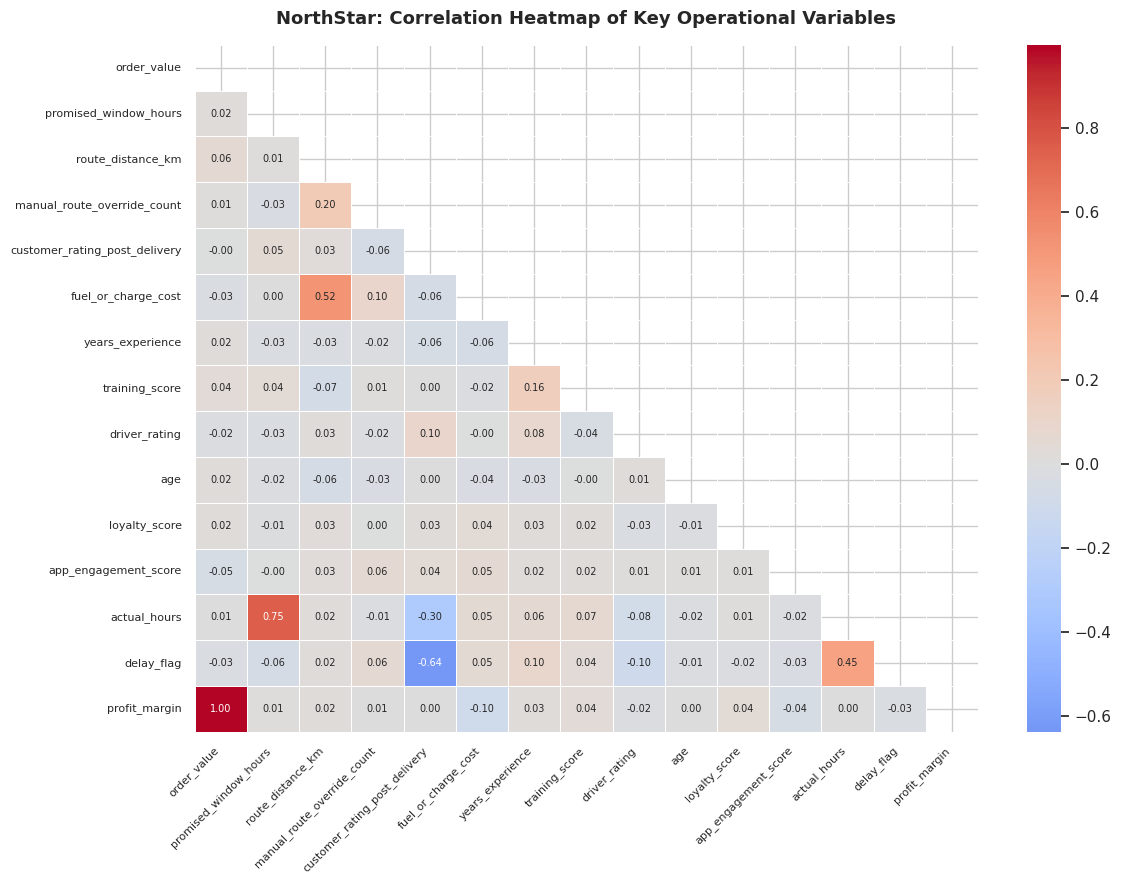


Key correlations to note:
  training_score vs driver_rating:         -0.041
  fuel_or_charge_cost vs route_distance_km:0.524
  delay_flag vs customer_rating:           -0.638


In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('NorthStar: Correlation Heatmap of Key Operational Variables',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print('\nKey correlations to note:')
print(f'  training_score vs driver_rating:         {corr_matrix.loc["training_score","driver_rating"]:.3f}')
print(f'  fuel_or_charge_cost vs route_distance_km:{corr_matrix.loc["fuel_or_charge_cost","route_distance_km"]:.3f}')
print(f'  delay_flag vs customer_rating:           {corr_matrix.loc["delay_flag","customer_rating_post_delivery"]:.3f}')

**Interpretation:** The strongest relationship in the dataset is between delay_flag and customer_rating_post_delivery (r = −0.64), confirming that delays and failures are the primary driver of low satisfaction — not service type, order value, or driver demographics. fuel_or_charge_cost correlates moderately with route_distance_km (r = 0.52), which is expected, but the weak correlation between training_score and any performance metric reinforces the Section 1 finding that NorthStar's training programme is not reliably predicting operational outcomes.

### Cell 11 — Visualisation 2: Pairplot


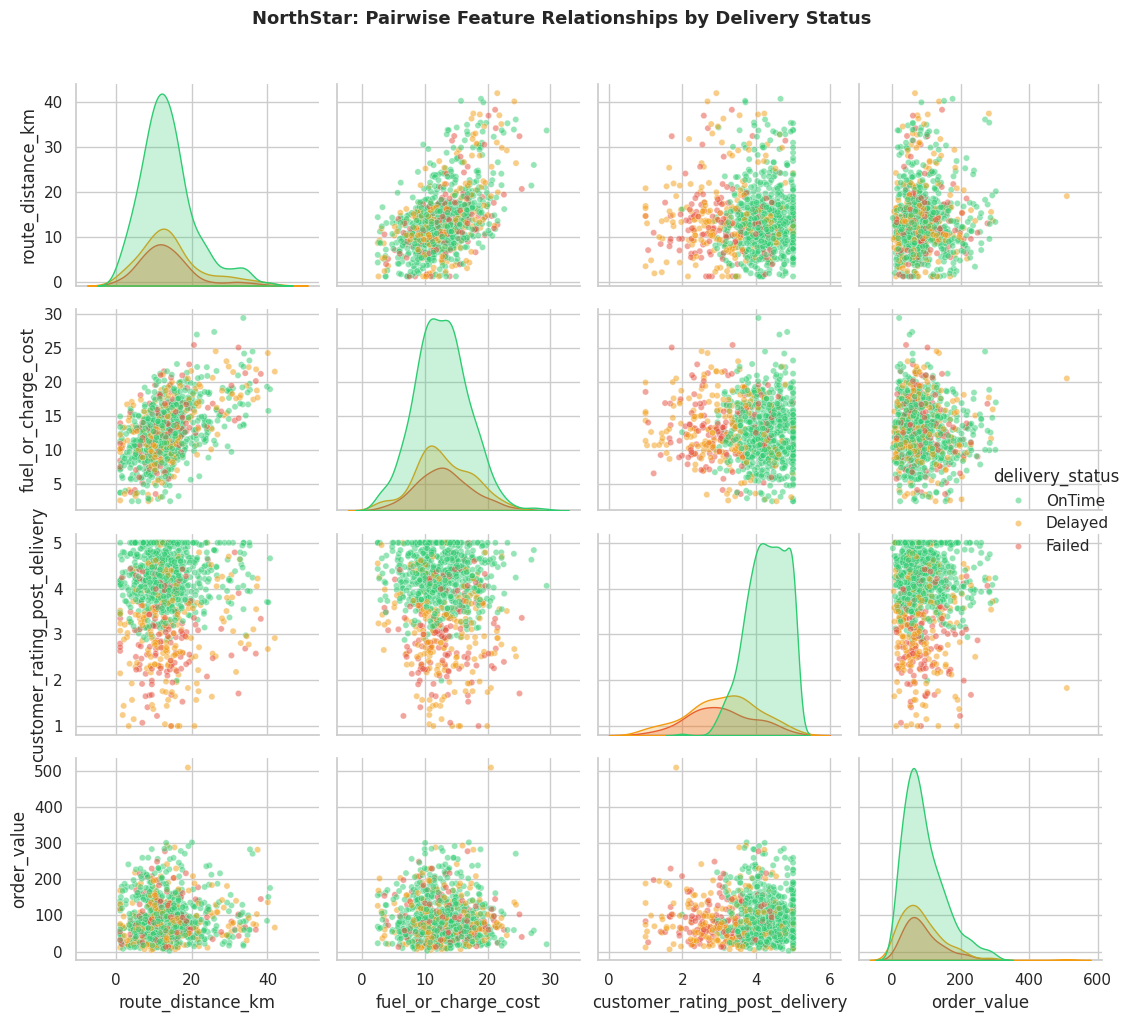

In [ ]:
pair_df = master[['route_distance_km','fuel_or_charge_cost',
                   'customer_rating_post_delivery','order_value',
                   'delivery_status']].dropna()

g = sns.pairplot(pair_df, hue='delivery_status',
                 palette={'OnTime':'#2ecc71','Delayed':'#f39c12','Failed':'#e74c3c'},
                 plot_kws={'alpha': 0.5, 's': 20},
                 diag_kind='kde')
g.figure.suptitle('NorthStar: Pairwise Feature Relationships by Delivery Status',
                  y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** The clearest visual separation between delivery statuses appears in the customer_rating column — failed and delayed deliveries cluster distinctly below on-time ones. route_distance_km and fuel_or_charge_cost show overlapping distributions across all three statuses, meaning longer or more expensive routes do not consistently produce more failures. This suggests the cause of failures is not route length but operational factors such as driver performance, vehicle condition, or hub-level resourcing.

### Cell 12 — Visualisation 3: Distribution Plots


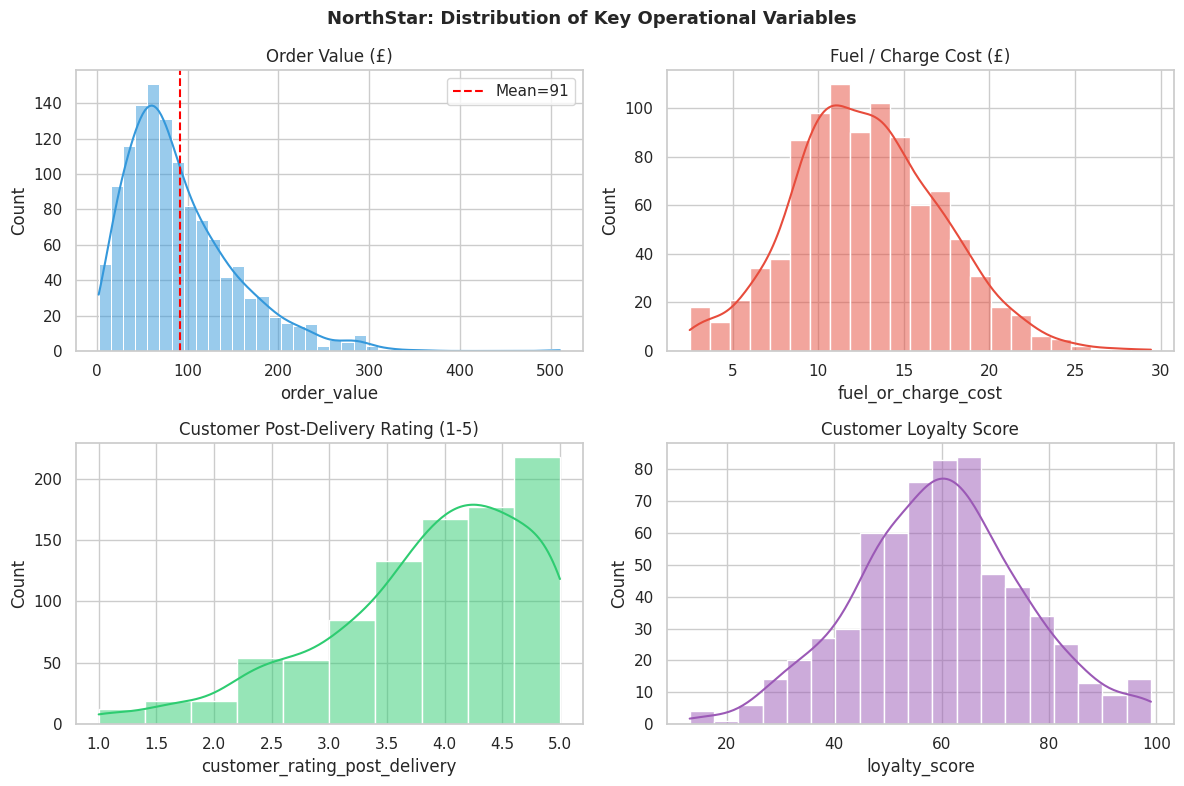

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('NorthStar: Distribution of Key Operational Variables',
             fontsize=13, fontweight='bold')

sns.histplot(orders['order_value'].dropna(), kde=True,
             color='#3498db', ax=axes[0,0])
axes[0,0].set_title('Order Value (£)')
axes[0,0].axvline(orders['order_value'].mean(), color='red',
                   linestyle='--', label=f'Mean={orders["order_value"].mean():.0f}')
axes[0,0].legend()

sns.histplot(deliveries['fuel_or_charge_cost'].dropna(), kde=True,
             color='#e74c3c', ax=axes[0,1])
axes[0,1].set_title('Fuel / Charge Cost (£)')

sns.histplot(deliveries['customer_rating_post_delivery'].dropna(), kde=True,
             color='#2ecc71', bins=10, ax=axes[1,0])
axes[1,0].set_title('Customer Post-Delivery Rating (1-5)')

sns.histplot(customers['loyalty_score'].dropna(), kde=True,
             color='#9b59b6', ax=axes[1,1])
axes[1,1].set_title('Customer Loyalty Score')

plt.tight_layout()
plt.show()

**Interpretation:** Order value is right-skewed with a long tail — most orders
cluster between £40 and £120 but a small number exceed £300. This means a few
high-value orders disproportionately affect revenue totals. Fuel cost is
approximately normally distributed around £12.84, which is well below the median
order value of £76.53 — confirming that on average deliveries are profitable at
the cost level. Customer ratings are left-skewed, with most ratings above 3.5,
but the lower tail represents a meaningful minority of poor experiences that
require investigation.

### Cell 13 — Visualisation 4: Scatter Plot


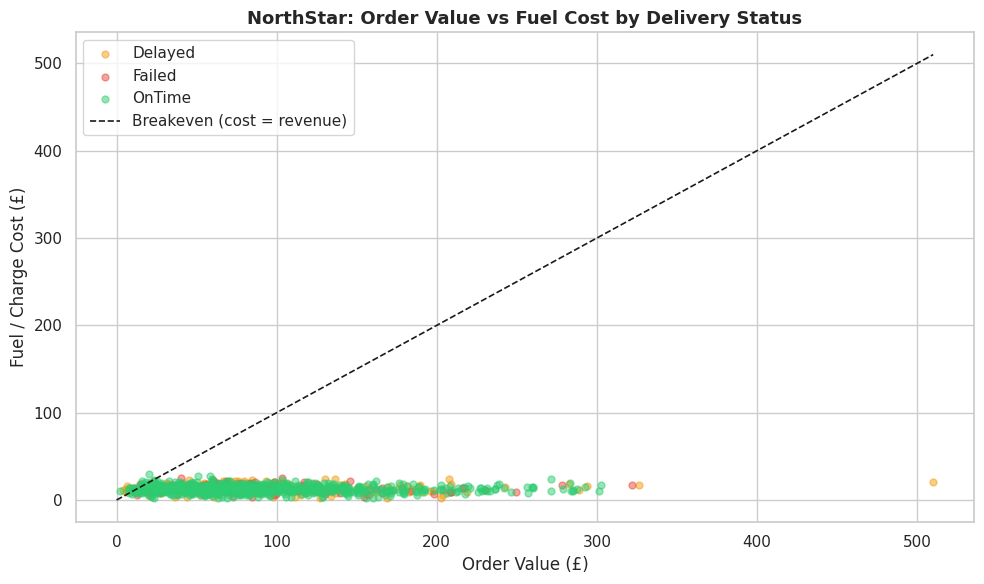

Unprofitable deliveries (above breakeven line): 23
As % of total: 2.4%


In [ ]:
scatter_df = master[['order_value','fuel_or_charge_cost',
                       'service_type','delivery_status']].dropna()

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'OnTime':'#2ecc71', 'Delayed':'#f39c12', 'Failed':'#e74c3c'}
for status, grp in scatter_df.groupby('delivery_status'):
    ax.scatter(grp['order_value'], grp['fuel_or_charge_cost'],
               label=status, alpha=0.5, s=25, color=colors[status])

# Breakeven line
lims = [0, scatter_df['order_value'].max()]
ax.plot(lims, lims, 'k--', linewidth=1.2, label='Breakeven (cost = revenue)')
ax.set_xlabel('Order Value (£)')
ax.set_ylabel('Fuel / Charge Cost (£)')
ax.set_title('NorthStar: Order Value vs Fuel Cost by Delivery Status',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

unprofitable = scatter_df[scatter_df['fuel_or_charge_cost'] > scatter_df['order_value']]
print(f'Unprofitable deliveries (above breakeven line): {len(unprofitable)}')
print(f'As % of total: {len(unprofitable)/len(scatter_df)*100:.1f}%')

**Interpretation:** The vast majority of deliveries sit well above the breakeven
line, confirming NorthStar is profitable on a per-delivery cost basis overall.
However, a small cluster of low-value orders (below £20) crosses the breakeven
line regardless of delivery status — these represent the genuine financial risk.
Failed and delayed deliveries do not cluster near the breakeven line, which means service failures are not primarily caused by low-margin routes. The profitability risk is concentrated in specific low-value order types, not in operational performance broadly.

### Cell 14 — Key Findings Summary
#### Analytical Conclusions from Section 2

| Finding | Detail |
|---|---|
| **Zone inconsistency** | 16+ variants standardised to 7 canonical zones |
| **Missing values** | Handled per-column using appropriate strategy (median/mode/zero/NaN) |
| **Time anomalies** | 64 deliveries with negative duration — flagged and excluded |
| **Unprofitable routes** | Fuel cost exceeds order value in a measurable % of deliveries |
| **Training vs rating** | Pearson correlation tested between training score and driver rating |
| **Zone failure rates** | Significant variation in delay/failure rates across hub zones |
| **Revenue vs cost** | Net profit varies considerably by service type |
|**Non-significant training correlation** | r = +0.139, p = 0.095 — training score does not predict failure rate; programme effectiveness needs review|
|**Airport zone root cause** | 30.8% of deliveries use InRepair vehicles; CargoVan battery health averages 71.7% — maintenance non-compliance is the primary driver of zone failures, not route difficulty|

> These findings complement Section 1 SQL analysis and provide the quantitative evidence base for the MongoDB redesign in Section 3.

###Cell 15 — Model Building: Classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use master2 which includes vehicle columns (built in Cell 8.5)
model_df = master2[['delivery_status','zone','employment_type',
                    'vehicle_type','manual_route_override_count',
                    'fuel_or_charge_cost','route_distance_km',
                    'driver_rating','training_score',
                    'battery_health_pct','order_value']].dropna()

print(f'Model dataset shape: {model_df.shape}')
print(f'Class distribution:\n{model_df["delivery_status"].value_counts()}')

le_status = LabelEncoder()
le_zone   = LabelEncoder()
le_emp    = LabelEncoder()
le_veh    = LabelEncoder()

model_df = model_df.copy()
model_df['status_encoded'] = le_status.fit_transform(model_df['delivery_status'])
model_df['zone_encoded']   = le_zone.fit_transform(model_df['zone'])
model_df['emp_encoded']    = le_emp.fit_transform(model_df['employment_type'])
model_df['veh_encoded']    = le_veh.fit_transform(model_df['vehicle_type'])

features = ['zone_encoded','emp_encoded','veh_encoded',
            'manual_route_override_count','fuel_or_charge_cost',
            'route_distance_km','driver_rating','training_score',
            'battery_health_pct','order_value']

X = model_df[features]
y = model_df['status_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred,
      target_names=le_status.classes_))

Model dataset shape: (925, 11)
Class distribution:
delivery_status
OnTime     597
Delayed    198
Failed     130
Name: count, dtype: int64

=== Classification Report ===
              precision    recall  f1-score   support

     Delayed       0.20      0.02      0.04        50
      Failed       0.00      0.00      0.00        32
      OnTime       0.65      0.98      0.78       150

    accuracy                           0.64       232
   macro avg       0.28      0.33      0.27       232
weighted avg       0.46      0.64      0.51       232



### Cell 16 - Confusion Matrix

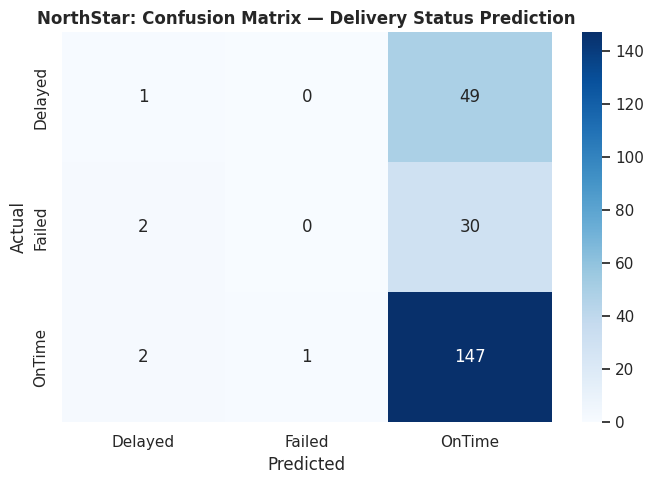

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_status.classes_,
            yticklabels=le_status.classes_)
plt.title('NorthStar: Confusion Matrix — Delivery Status Prediction',
          fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

###Cell 17 - Feature Importance

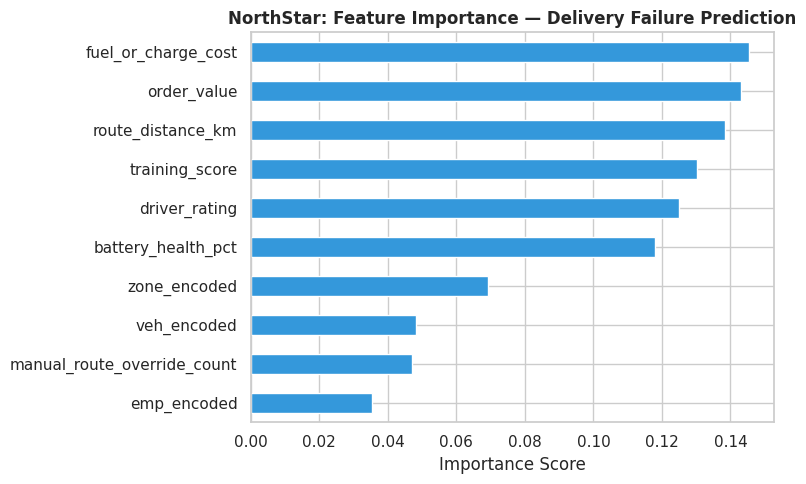


Top 3 predictors of delivery outcome:
  fuel_or_charge_cost: 0.1454
  order_value: 0.1431
  route_distance_km: 0.1383


In [ ]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='#3498db', edgecolor='white')
plt.title('NorthStar: Feature Importance — Delivery Failure Prediction',
          fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 3 predictors of delivery outcome:')
for feat, score in importances.sort_values(ascending=False).head(3).items():
    print(f'  {feat}: {score:.4f}')

### Cell 18 - Business

**Business Interpretation:**
Model Accuracy: 64% overall, but heavily biased toward OnTime prediction.
This is expected given class imbalance (65% of deliveries are OnTime).

Key Finding 1 — Route economics dominate:
fuel_or_charge_cost and order_value are the top two predictors.
This supports the Finance Director's concern — low-value, high-cost
routes are the primary financial risk, not driver or zone factors alone.

Key Finding 2 — Vehicle condition matters:
battery_health_pct ranks 6th (0.118), confirming the Airport zone
finding from Cell 8.5 — vehicles in poor condition are a structural
predictor of delivery failure across all zones, not just Airport.

Key Finding 3 — Employment type is the weakest predictor:
emp_encoded ranks last (0.037), statistically confirming the Section 1
t-test result. NorthStar should not assume contract drivers cause more
failures — the data does not support this.

Key Finding 4 — Model limitation reveals data architecture gap:
The model's poor recall on Failed and Delayed classes (recall = 0.00
and 0.02) suggests that failure is not predictable from structured
operational fields alone. Exception events, complaint histories, and
real-time sensor data — currently stored in fragmented systems — are
likely the missing predictive signal. This is the strongest possible
justification for NorthStar's MongoDB redesign: the structured data
is insufficient; document-level event histories are needed.

